# Preprocessing Spotify Churn Data - Panther Component Analyzers

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, mutual_info_regression, RFECV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.svm import SVC

from scipy.stats import mode

In [ ]:
# For consistent styling
sns.set_theme(style='white')
plt.style.use('seaborn-v0_8-poster')

## Data Fetching and EDA

In [ ]:
# Install dependencies as needed:
# !pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nabihazahid/spotify-dataset-for-churn-analysis",
  "spotify_churn_dataset.csv"
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

100%|██████████| 382k/382k [00:00<00:00, 12.1MB/s]


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


### Data Dictionary
Rows: Each row represents a unique Spotify user.

Columns (Features):

user_id → Unique identifier for each user

gender → User gender (Male/Female/Other)

age → User age

country → User location

subscription_type → Type of Spotify subscription (Free, Premium, Family, Student)

listening_time → Minutes spent listening per day

songs_played_per_day → Number of songs played daily

skip_rate → Percentage of songs skipped

device_type → Device used (Mobile, Desktop, Web)

ads_listened_per_week → Number of ads heard per week

offline_listening → Offline mode usage

is_churned → Target variable (0 = Active, 1 = Churned)

**Finding**: `ads_listened_to_per_week` and `subscription_type` could contain potential leakage. Only free users listen to ads on Spotify.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In [ ]:
# This shows the summary statistics for each numerical column.
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [ ]:
# This reveals the summary statistics for each categorical column (the rest of the columns).
df.select_dtypes(include = ['category', 'object']).describe()

,gender,country,subscription_type,device_type
count,8000,8000,8000,8000
unique,3,8,4,3
top,Male,AU,Premium,Desktop
freq,2691,1034,2115,2778


### Inspecting the target feature (`is_churned`)

In [ ]:
# Now it's time to find any columns with missing values.
# Spoiler: there is none.
df.loc[:, df.isna().any()]

""
0
1
2
3
4
...
7995
7996
7997
7998


**Finding**: `is_churned` has no missing values

In [ ]:
# Our target feature
y = df['is_churned']
y.value_counts()

,count
is_churned,
0,5929
1,2071


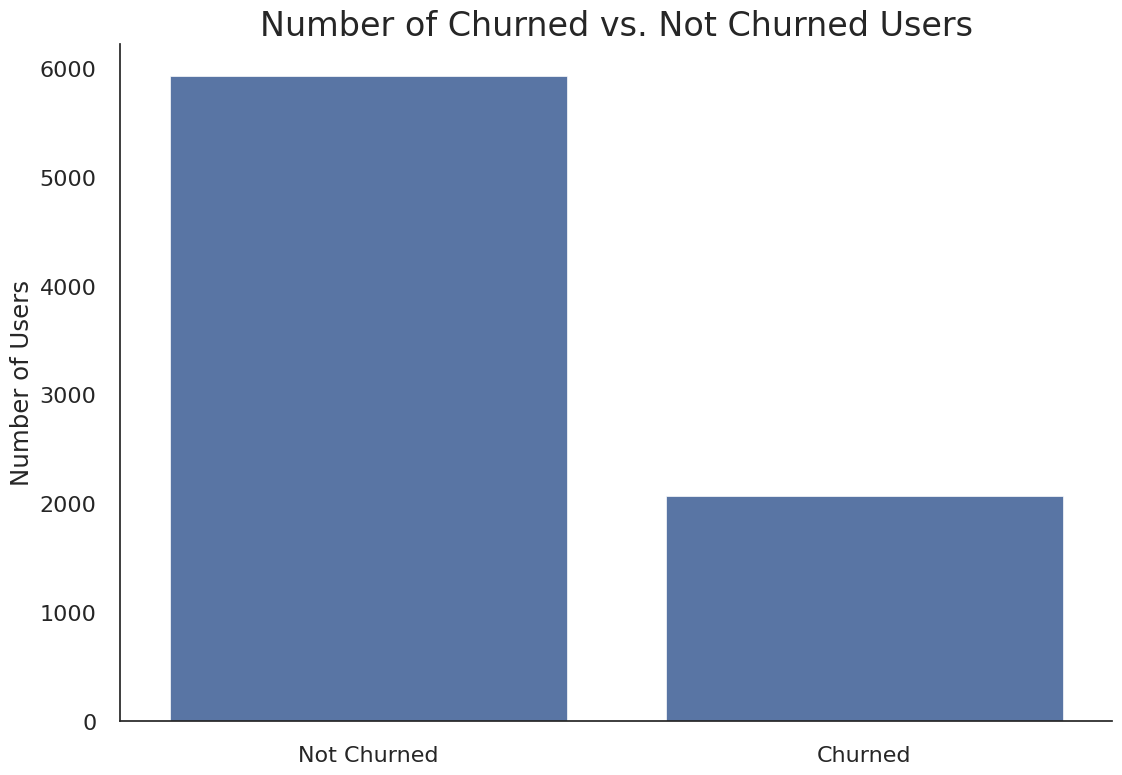

In [ ]:
ax = sns.countplot(x = y)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Churned', 'Churned'])
ax.set_title('Number of Churned vs. Not Churned Users', fontsize=24)
ax.set_xlabel('')
ax.set_ylabel('Number of Users');
sns.despine();

**Findings**: `is_churned` is imbalanced, indicating we should consider `recall`, `precision`, `f1` or `ROC AUC` as our scoring metric in model evaluation.

In [ ]:
X = df.copy()
X.drop(columns = ['is_churned'], inplace = True, errors = 'ignore')
X.head() # The dataframe with the remaining features

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1


In [ ]:
X.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000


### Duplicate Detection

In [ ]:
df.duplicated().any()

np.False_

**Finding**: We have no duplicate instances

### Looking for outliers and anamolies

In [ ]:
outlier_df = pd.DataFrame({'Number of Outliers': [], 'Proportion of Outliers': []})

In [ ]:
def outlier_counts(series):
  """
  Author: Elizabeth, Debra Ritter
  TODO: Add description, params etc.
  """
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = (series < lower_bound) | (series > upper_bound)
  return outliers.sum()

# No need for user_id in our columns or offline_listening
X_ratio = X.select_dtypes(include=['number']).drop(columns=['user_id',
                                                              'offline_listening'])

ratio_df = X_ratio.apply(outlier_counts).rename('Number of Outliers').to_frame()
outlier_df['Percentage of Outliers'] = round(((outlier_df['Number of Outliers'] / X_ratio.shape[0]) * 100),
                                             2)
ratio_df

,Number of Outliers
age,0
listening_time,0
songs_played_per_day,0
skip_rate,0
ads_listened_per_week,1683


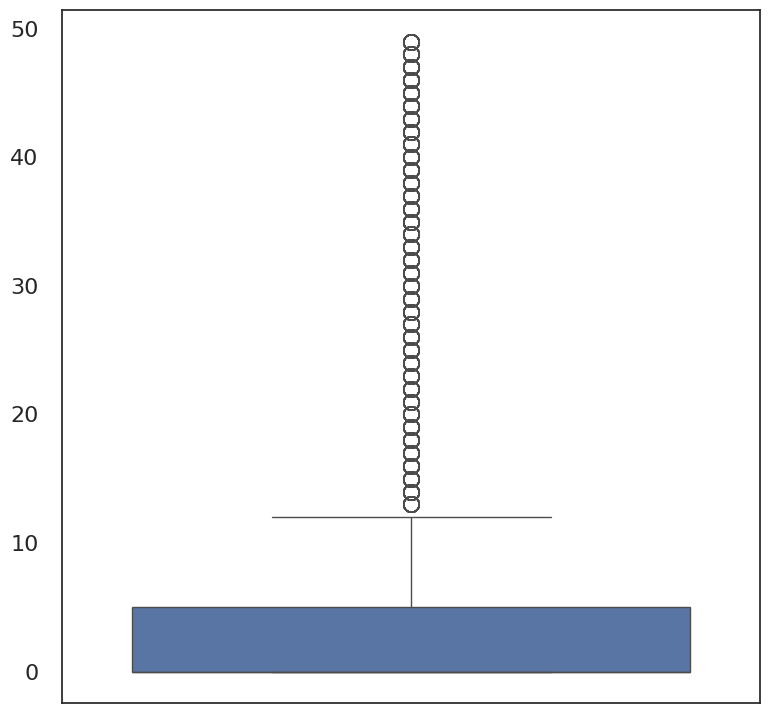

In [ ]:
fig, ax = plt.subplots(figsize = (9, 9))
ax = sns.boxplot(data = X['ads_listened_per_week'].values.tolist())

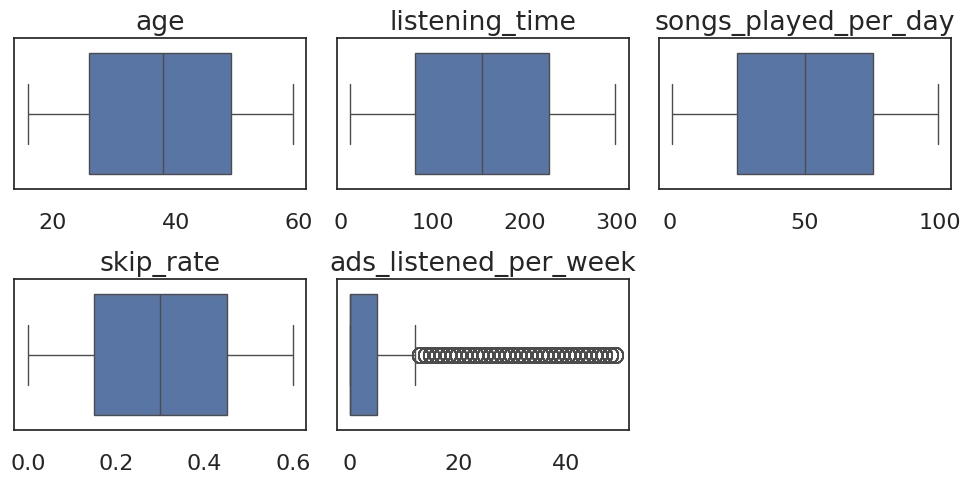

In [ ]:
"""
Author: Debra Ritter

A boxplot of ordered columns in the dataset.
"""
fig, ax = plt.subplots(2, 3, figsize = (10, 5))
ax = ax.flatten()

for i, col in enumerate(X_ratio.columns):
  if i >= len(ax):
    break
  sns.boxplot(x=X_ratio[col], ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel('')

ax[5].set_visible(False)
plt.tight_layout()
plt.show()

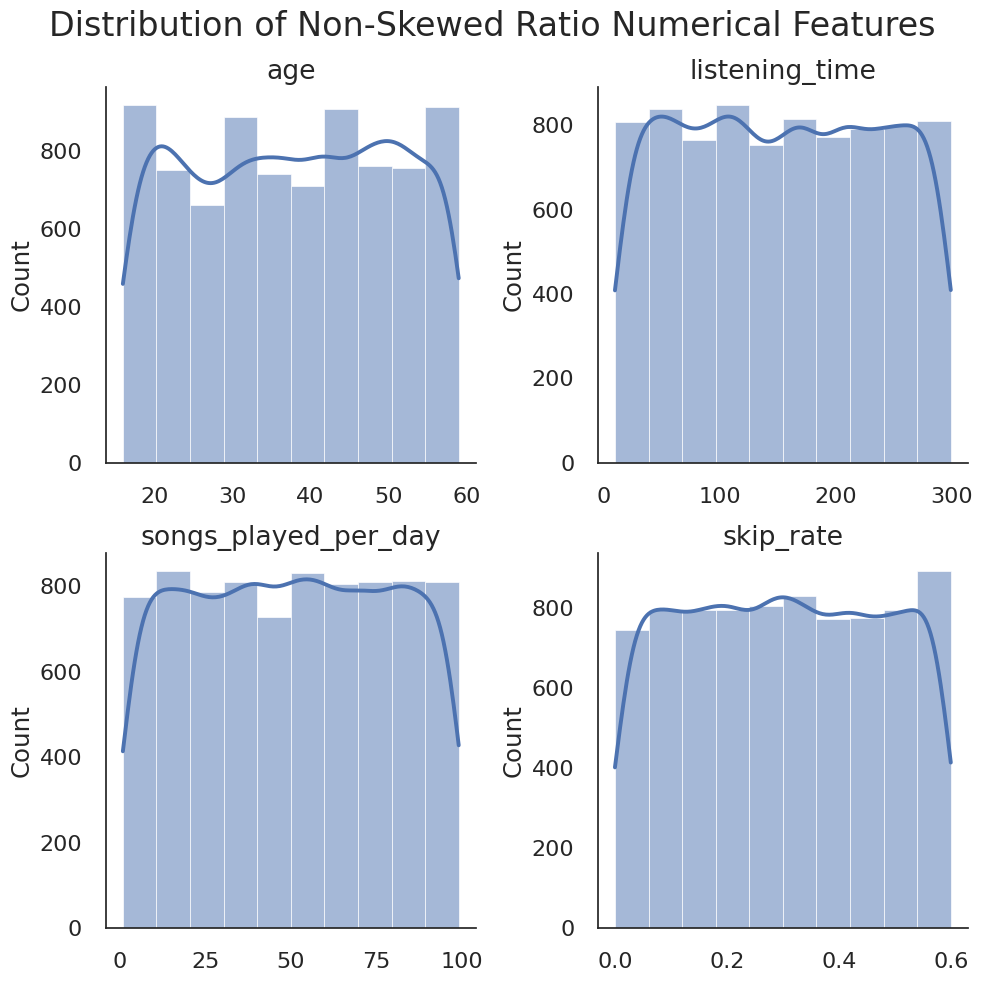

In [ ]:
X_ordered_without_ads = X_ratio.drop(columns = ['ads_listened_per_week'])
fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax = ax.flatten()

for i, col in enumerate(X_ordered_without_ads.columns):
  if i >= len(ax):
    break

  sns.histplot(data = X_ratio, x = col, kde = True, ax = ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel('')

fig.suptitle('Distribution of Non-Skewed Ratio Numerical Features', fontsize=24)
sns.despine()

plt.tight_layout()


**Findings**: The categories `listening_time`, `songs_played_per_day` and `skip_rate` are uniformly distributed.

The category `age` has jumps in age and needs to be investigated further

The category `ads_listened_to_per_week` has many zero values, likely from those who aren't free tier users in the `subscription_type` feature.

### Investigation of `age`

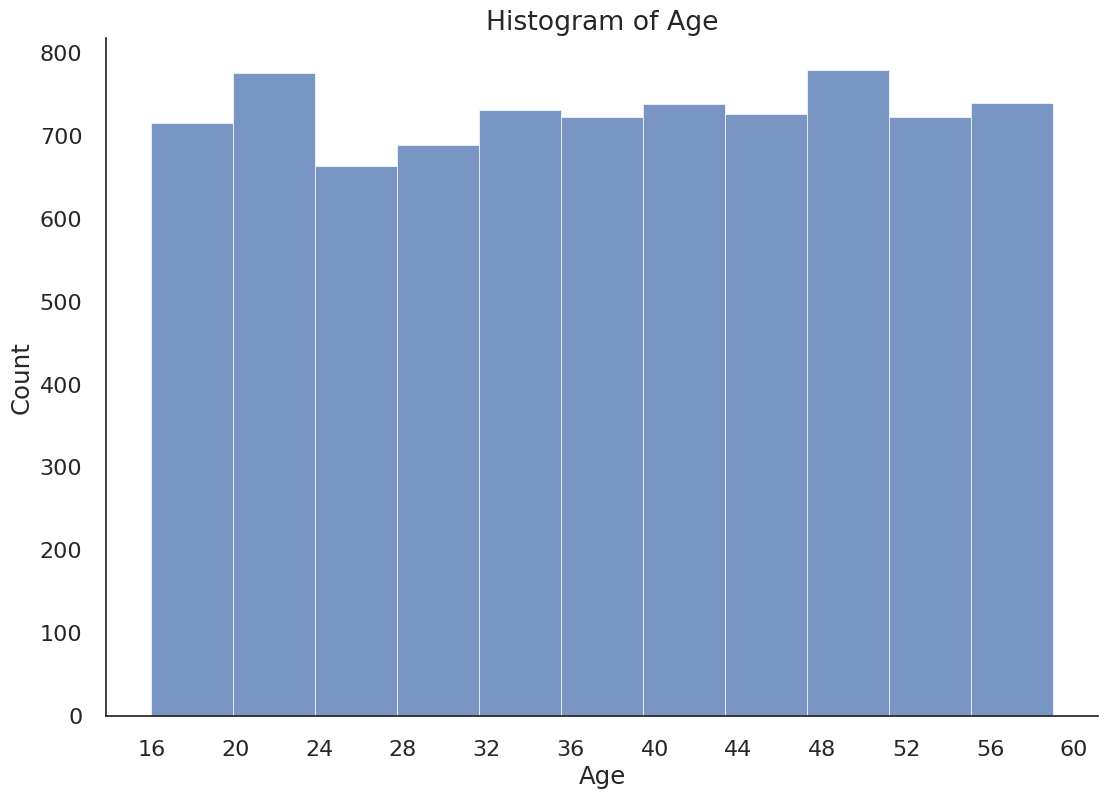

In [ ]:
min_age = X['age'].min()
max_age = X['age'].max()

# Each bar corresponds to one year
ax = sns.histplot(data = X, x = 'age', bins=(((max_age + 1) - min_age)) // 4);
ax.set_title('Histogram of Age');
ax.set_xlabel('Age');
ax.set_xticks([16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60]);
sns.despine();

**Findings**: This is a case of histograms lying to us, our trend of random spikes in `age` goes away when we increase the number of bins.

However we have found a new problem! It's statistically unlikely that so many of these users are aged 58. We need to deal with this

### Investigation of `ads_listened_to_per_week`

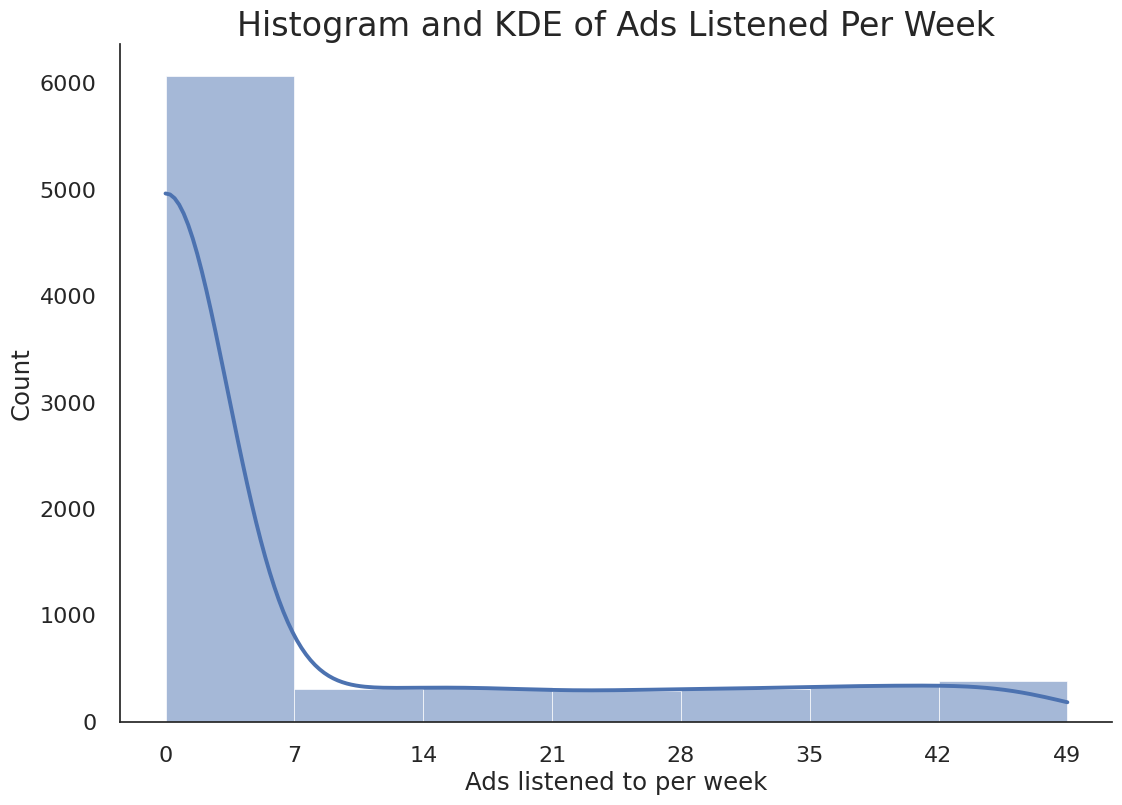

In [ ]:
fig, ax = plt.subplots()
ax = sns.histplot(data = X,
                  x = 'ads_listened_per_week',
                  kde = True,
                  kde_kws = {"bw_adjust": 1.5, "cut" : 0},
                  bins = 7)
ax.set_xticks(np.arange(0, 50, 7));
ax.set_title('Histogram and KDE of Ads Listened Per Week', fontsize=24);
ax.set_xlabel('Ads listened to per week')
sns.despine();

In [ ]:
(df['ads_listened_per_week'] == 0).sum()

np.int64(5982)

**Findings**: The feature `ads_listened_per_week` has a high number of zero values. It's worthwhile to check if all these values only belong to the `Free` categorical value in the `subscription_type` feature, we so can make sure our data is correct.

We do the following groupbys to make sure **only** free tier users are the ones listening to ads

In [ ]:

df[['subscription_type', 'ads_listened_per_week']].groupby('subscription_type').value_counts()

subscription_type  ads_listened_per_week
Family             0                        1908
Free               47                         58
                   44                         57
                   16                         55
                   35                         53
                   39                         53
                   41                         53
                   46                         51
                   45                         50
                   13                         49
                   18                         49
                   26                         49
                   36                         48
                   20                         47
                   32                         47
                   38                         47
                   12                         46
                   30                         46
                   15                         45
                   31                         45
                   40                         45
                   43                         45
                   9                          44
                   25                         44
                   34                         44
                   37                         44
                   8                          43
                   11                         43
                   17                         43
                   22                         43
                   27                         43
                   28                         43
                   42                         43
                   5                          42
                   10                         42
                   14                         42
                   19                         42
                   24                         42
                   33                         40
                   6                          38
                   29                         38
                   49                         38
                   7                          37
                   48                         36
                   21                         34
                   23                         32
Premium            0                        2115
Student            0                        1959
Name: count, dtype: int64

**Findings**: Only the `free` category in our `subscription_type` column has non-zero ad values (i.e. only free users listen to ads)

In [ ]:
sub_vs_churned = df[['subscription_type', 'is_churned']].groupby('subscription_type').value_counts()
sub_vs_churned

subscription_type  is_churned
Family             0             1383
                   1              525
Free               0             1515
                   1              503
Premium            0             1585
                   1              530
Student            0             1446
                   1              513
Name: count, dtype: int64

In [ ]:
# Before we create the bar chart, we have to convert `sub_vs_churned`into a
# tidy format, which is what seaborn expects

# Convert to tidy_format
sub_vs_churned = sub_vs_churned.to_frame().T.melt()
sub_vs_churned

,subscription_type,is_churned,value
0,Family,0,1383
1,Family,1,525
2,Free,0,1515
3,Free,1,503
4,Premium,0,1585
5,Premium,1,530
6,Student,0,1446
7,Student,1,513


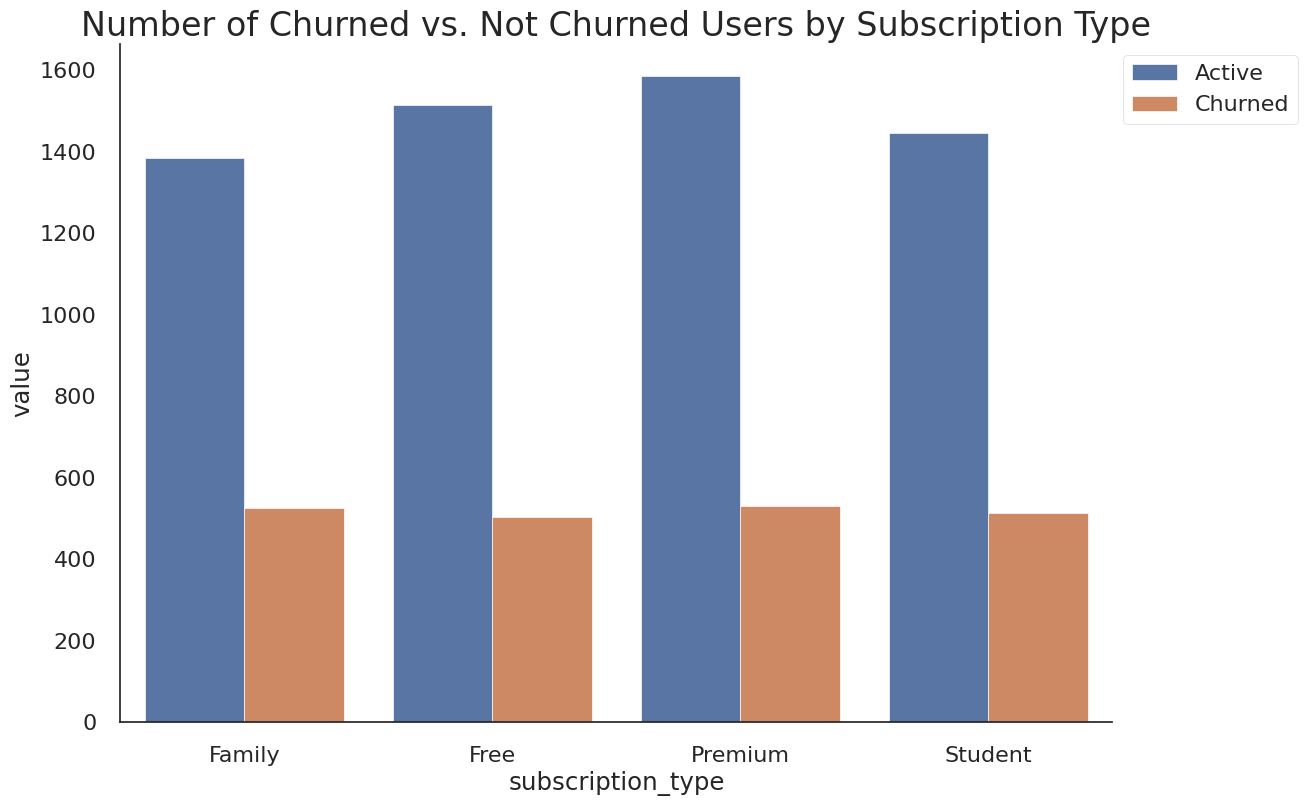

In [ ]:
ax = sns.barplot(data = sub_vs_churned,
            x = 'subscription_type',
            y = 'value',
            hue='is_churned');

# Used for changing the legend values from [0, 1] to ['Not Churned', 'Churned']
handles, curr_labels = ax.get_legend_handles_labels()
new_labels = ['Active', 'Churned']

ax.legend(loc='upper left',
          bbox_to_anchor=(1, 1),
          labels=new_labels,
          handles=handles)
ax.set_title('Number of Churned vs. Not Churned Users by Subscription Type', fontsize=24);
sns.despine();

**Finding**: Our dataset looks suspicially artifical, as for every subscription tier, the proportion of churned and not churned is roughly the same.

In [ ]:
free_sub = X[X['subscription_type'] == 'Free'].describe()
free_sub

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening
count,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2018.000000,2018.0
mean,3991.758176,37.287909,154.997027,49.204163,0.300922,27.527750,0.0
std,2296.840926,12.738974,84.467723,28.706643,0.175472,12.982368,0.0
min,1.000000,16.000000,10.000000,1.000000,0.000000,5.000000,0.0
25%,1980.750000,26.000000,82.000000,24.000000,0.150000,16.000000,0.0
50%,4000.500000,37.000000,154.000000,49.000000,0.300000,28.000000,0.0
75%,5987.750000,48.000000,229.000000,74.000000,0.450000,39.000000,0.0
max,8000.000000,59.000000,299.000000,99.000000,0.600000,49.000000,0.0


In [ ]:
Q1 = free_sub.loc['25%', 'ads_listened_per_week']
Q3 = free_sub.loc['75%', 'ads_listened_per_week']
IQR = Q3 - Q1
IQR_min = Q1 - 1.5 * IQR
IQR_max = Q3 + 1.5 * IQR
free_ad_outliers = X[(X['ads_listened_per_week'] < IQR_min) | (X['ads_listened_per_week'] > IQR_max)]
print(f'Number of outliers from users with a free subscription: {len(free_ad_outliers)}')

Number of outliers from users with a free subscription: 0


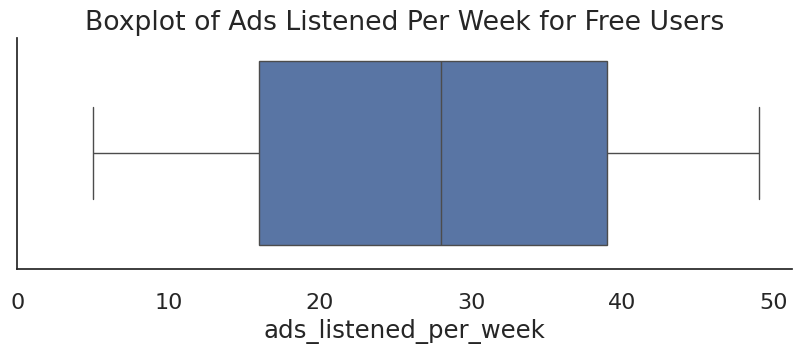

In [ ]:
fig, ax = plt.subplots(figsize = (10, 3))
ax = sns.boxplot(data = X[X['subscription_type'] == 'Free'], x = 'ads_listened_per_week')
ax.set_xticks([0, 10, 20, 30, 40, 50]);
ax.set_title('Boxplot of Ads Listened Per Week for Free Users');
sns.despine();

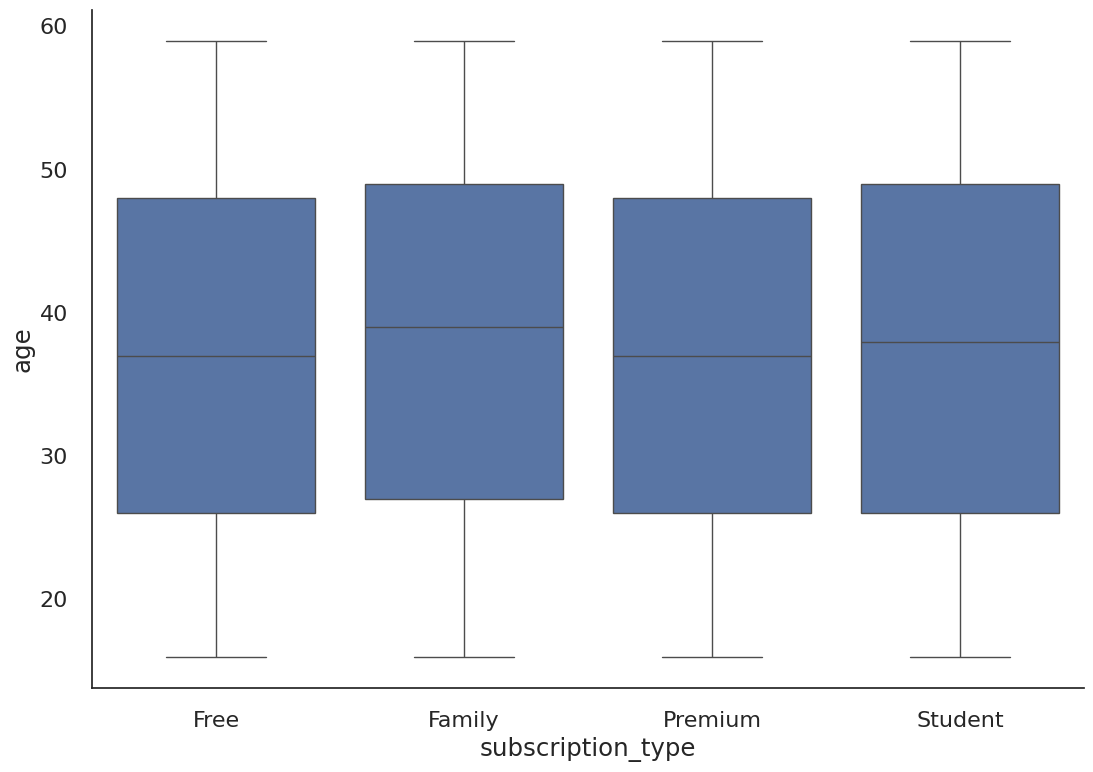

In [ ]:
sns.boxplot(data= X, x= 'subscription_type', y='age');
sns.despine();

<Axes: xlabel='listening_time', ylabel='Count'>

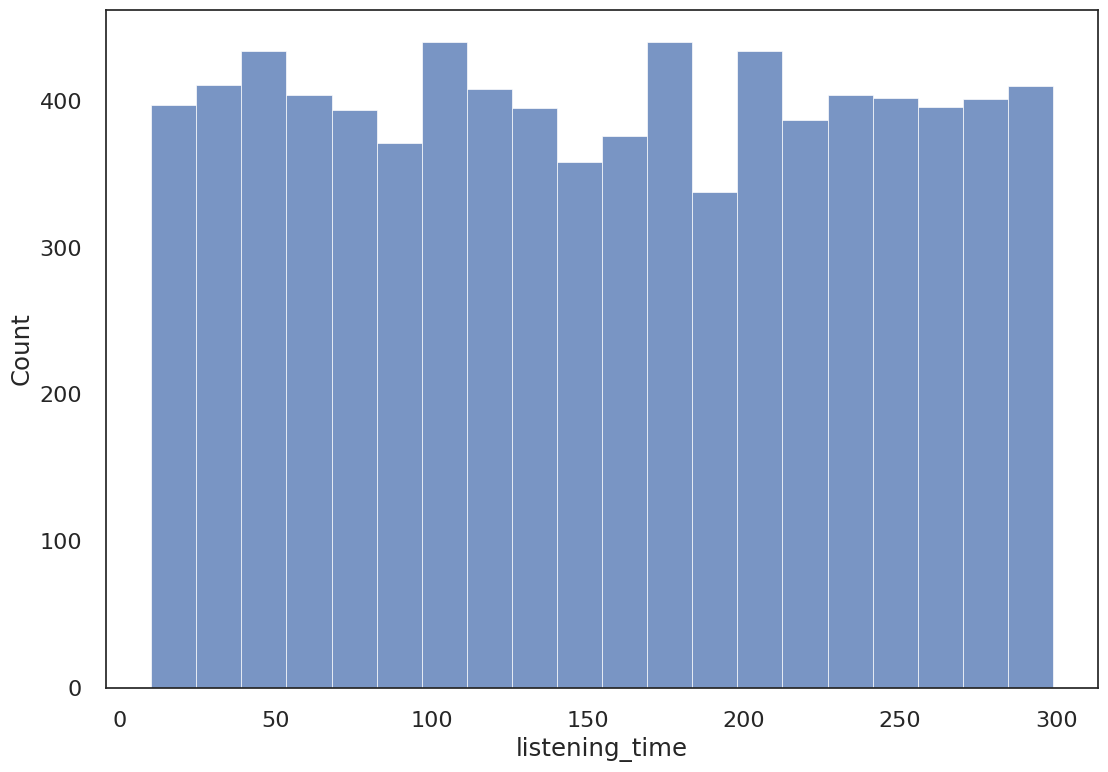

In [ ]:
sns.histplot(data= X, x='listening_time')

### Visualization of Categorical Columns

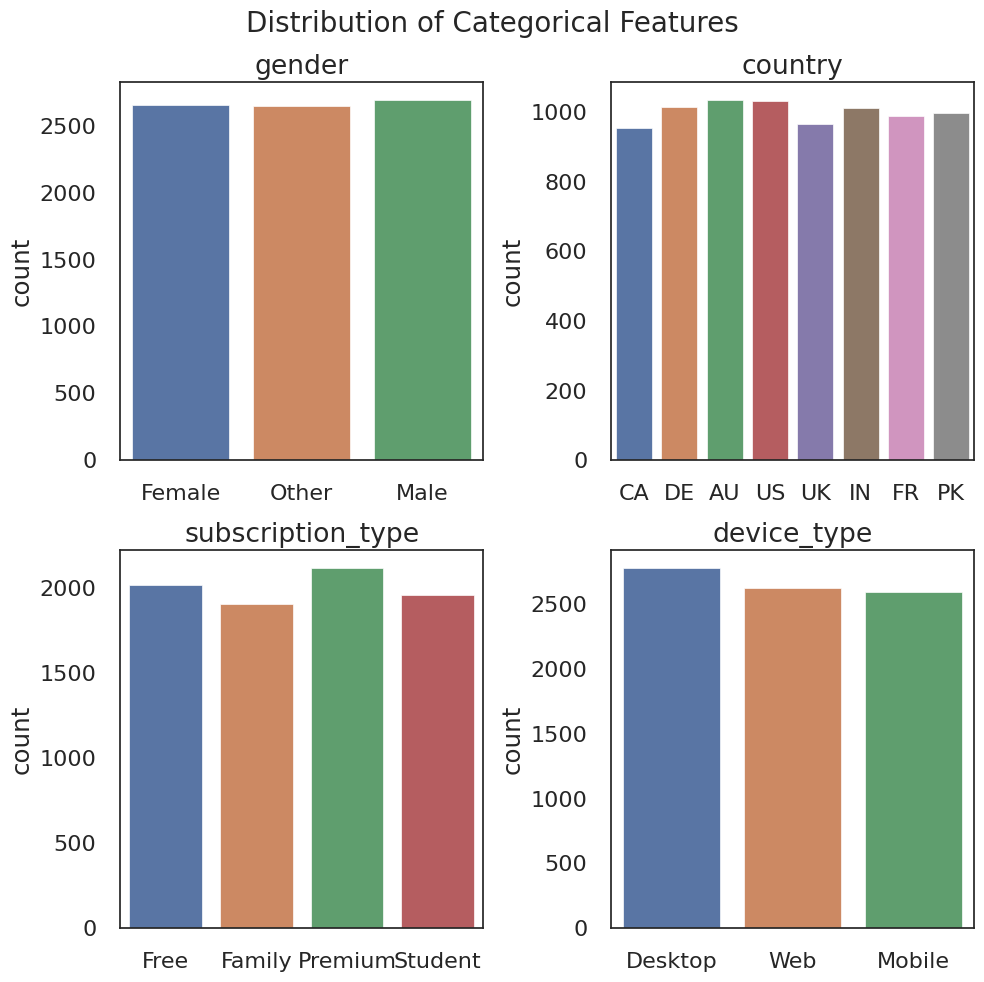

In [ ]:
categorical_columns = ['gender', 'country', 'subscription_type', 'device_type',
                       'offline_listening']

fig, ax = plt.subplots(2, 2, figsize = (10, 10))
ax = ax.flatten()

for i, col in enumerate(categorical_columns):
  if i >= len(ax):
    break

  ax[i] = sns.countplot(data = X, x = col, ax = ax[i], hue = col)
  ax[i].set_title(col)
  ax[i].set_xlabel('')

fig.suptitle('Distribution of Categorical Features', fontsize = 20)
plt.tight_layout()

**Findings**: Our categorical features are uniformly distributed

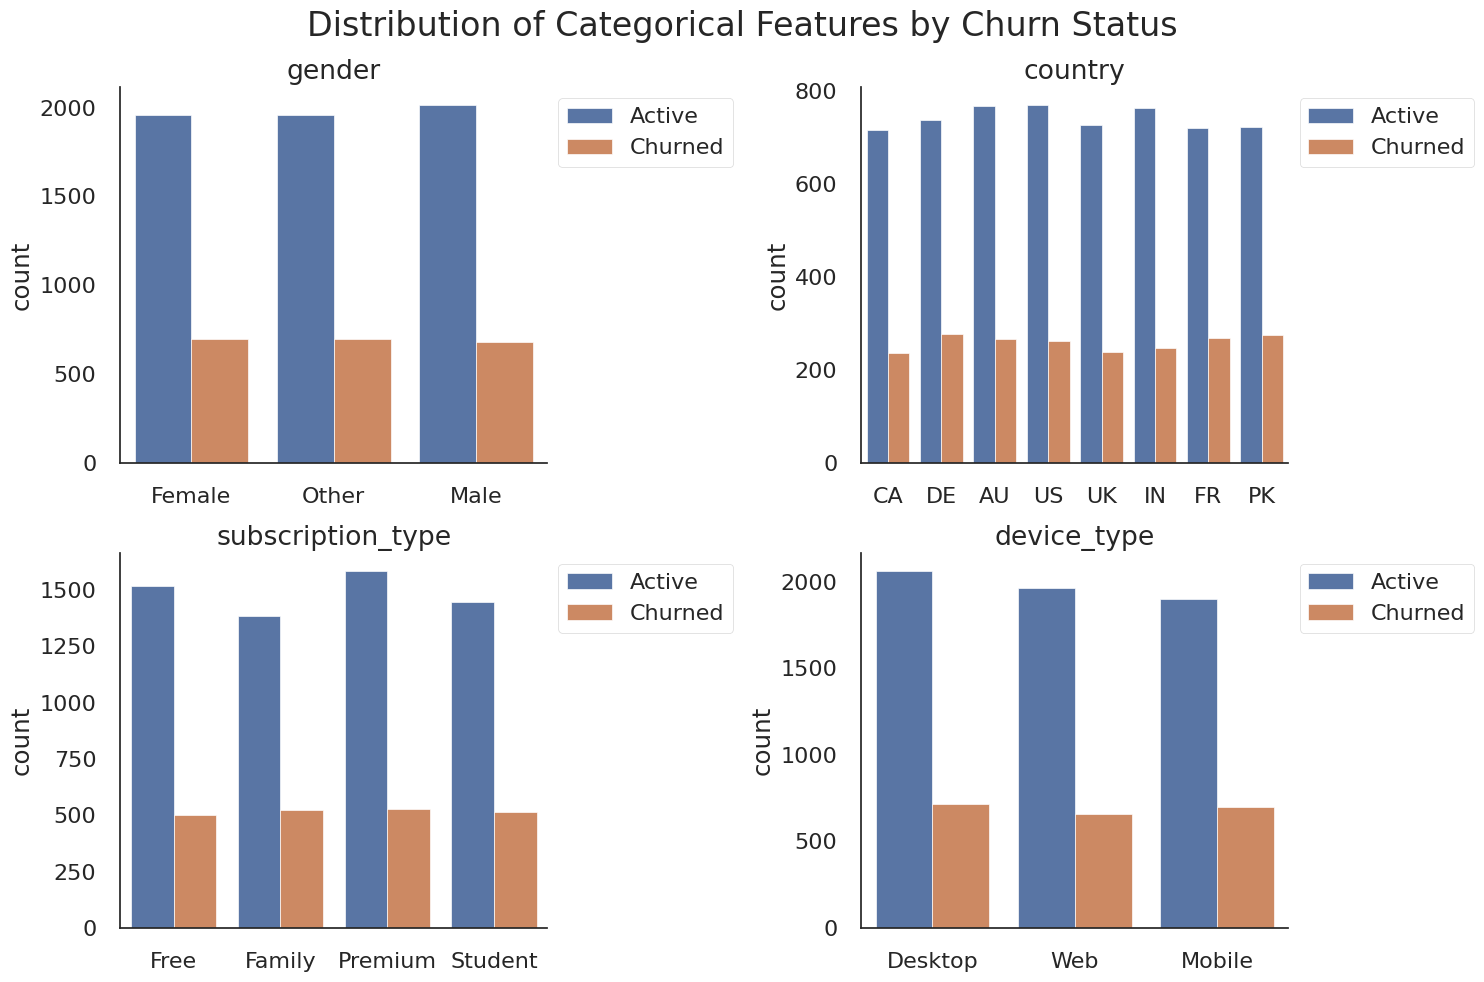

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (15, 10))
ax = ax.flatten()

for i, col in enumerate(categorical_columns):
  if i >= len(ax):
    break

  ax[i] = sns.countplot(data = df, x = col, ax = ax[i], hue = 'is_churned')
  ax[i].set_title(col)
  ax[i].set_xlabel('')

  handles, curr_labels = ax[i].get_legend_handles_labels()
  new_labels = ['Active', 'Churned']

  ax[i].legend(loc='upper left',
            bbox_to_anchor=(1, 1),
            labels=new_labels,
            handles=handles)

fig.suptitle('Distribution of Categorical Features by Churn Status', fontsize = 24)
sns.despine()
plt.tight_layout()

In [ ]:
y.value_counts(normalize=True)

,proportion
is_churned,
0,0.741125
1,0.258875


**Finding**: Throughout our categorical features, our proportion of Active:Churned being somewhere around 75:25 is somewhat constant. Indicating our data is synthetic

### Findings of EDA
- Size and Schema
  - Our data has $12$ features (one of which is the target `is_churned`), $6$ of which are numeric, and $5$ of which are categorical.
  - Our data has $8000$ instances
- Missing Values and Duplicates
  - Our data has no missing values or duplicates.
- Data Distributions
  - Numerical Data
    - All of our data is uniformly distributed except for `ads_listened_to_per_week`, which has majority ($5982$) zero values, making it sparse.
  - Categorical Data
    - All of our categorical features are nominal, except for `subscription_type`, which is ordinal.
    - All of the categories in our categorical features roughly have an even split of categories, making them uniformly distributed.

All of this indicates that our data is likely synthetic.

The `Free` tier in `subscription_type` is a bit confusing. `Free` users are reported as `Active` or `Churned`. However, it is impossible to know if these users had a subscription before or not. Regardless, they should not be in the `Active` category, but they shouldn't be in the `Churned` category either unless they previously had a subscription. We are leaving this for now.

Our data has potential leakage with `subscription_type`, if someone is a free tier user, they are much more likely to churn. Upon investigation, we found the proportion of values between Active and Churned was the same across subscription types.

## Scaling and Cleaning
How we're going to modify each feature:

category | modification
--------|------------|
`user_id`| drop
`gender` | One-Hot Encode
`age` | Standardize
`country` | One-Hot Encode
`subscription_type` | Ordinal Encode
`listening_time` | Standardize
`songs_played_per_day` | Standardize
`skip_rate` | Standardize
`device_type` | One-Hot Encode
`ads_listened_to_per_week` | Max-Abs Scale
`offline_listening` | None (Already binary variable)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Preprocessing pipeline

In [ ]:
# No need to delinate user_id, we'll drop it in the pipeline

# offline listening is included for the pipeline, but is redundant
nominal_features = ['gender', 'country', 'device_type', 'offline_listening']
ordinal_features = ['subscription_type']

# standard features is numerical features BESIDES ads_listended_to_per_week,
# which we'll max-abs scale
standard_features = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate']
max_abs_features = ['ads_listened_per_week']

In [ ]:
nominal_transformer = Pipeline(steps=[
    # Drop the first value in OHE to avoid redundancy
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

standard_transformer = Pipeline(steps=[
    ('standard', StandardScaler())
])

max_abs_transformer = Pipeline(steps=[
    ('max_abs', MaxAbsScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('nominal', nominal_transformer, nominal_features),
    ('ordinal', ordinal_transformer, ordinal_features),
    ('standard', standard_transformer, standard_features),
    ('max_abs', max_abs_transformer, max_abs_features)
    ],
    remainder='drop', # For user_id
    verbose_feature_names_out=True # For further graphical analysis, feature selection etc
)

preprocessor

ColumnTransformer(transformers=[('nominal',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'country', 'device_type',
                                  'offline_listening']),
                                ('ordinal',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder())]),
                                 ['subscription_type']),
                                ('standard',
                                 Pipeline(steps=[('standard',
                                                  StandardScaler())]),
                                 ['age', 'listening_time',
                                  'songs_played_per_day', 'skip_rate']),
                                ('max_abs',
                                 Pipeline(steps=[('max_abs', MaxAbsScaler())]),
                                 ['ads_listened_per_week'])])

In [ ]:
# This returns an ndarray
X_preprocessed = preprocessor.fit_transform(X_train)
X_preprocessed_names = preprocessor.get_feature_names_out()
len(X_preprocessed_names)

18

**Findings**: We have 18 features, which is close to ideal as per `Project_Description_TR_Fall_2025` phase 3

### Feature Elimination - Removing constant and quasiconstant features

While the way described in `HW_5` works, we can also check via mode.

That is for each feature, check if the count of the mode is greater than or the length of the feature column multiplied by the threshold.

In [ ]:
THRESHOLD = 0.99995
COL_LEN = X_preprocessed.shape[0] # 8000
# apply floor to make it an integer with a strict amount
THRESHOLD_LEN = np.floor(THRESHOLD * COL_LEN)

# mode() returns a `ModeResult` class
modes_info = mode(X_preprocessed, axis = 0)

modes_info

ModeResult(mode=array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  2.        ,  1.0434791 , -0.64876249,
       -0.38927558,  0.22415321,  0.        ]), count=array([4264, 4283, 5619, 5593, 5628, 5585, 5579, 5626, 5599, 4320, 4263,
       4801, 1724,  174,   34,   88,  133, 4801]))

In [ ]:
# We want the count of each mode
mode_counts = modes_info.count

quasi_constant_indices = [
    i for i in range(len(mode_counts))
    if mode_counts[i] >= THRESHOLD_LEN]

quasi_constant_indices

[]

**Findings**: We have no constant or quasi-constant features, as the length of our `quasi_constant_indices` is `0` (it is empty)

### Feature Elimination - Remove Features With High Mutual Information
Because most of our features are categorical (including our target), using a pearson correlation matrix such as `df.corr()` is inadequate. It makes sense to use mutual information instead.

`sklearn` has two implementation of mutual information:
- `mutual_info_classif` for when our target variable is discrete.
- `mutual_info_regression` for when our target variable is continuous.

We'll build a mutual information matrix with each feature being a target variable.

So we need to:
- Determine when to use the classifier versus regressor per column
- Manually build our matrix
- plot our matrix
- Determine feature elimination

In [ ]:
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns = X_preprocessed_names)
X_preprocessed_df.head()

,nominal__gender_Male,nominal__gender_Other,nominal__country_CA,nominal__country_DE,nominal__country_FR,nominal__country_IN,nominal__country_PK,nominal__country_UK,nominal__country_US,nominal__device_type_Mobile,nominal__device_type_Web,nominal__offline_listening_1,ordinal__subscription_type,standard__age,standard__listening_time,standard__songs_played_per_day,standard__skip_rate,max_abs__ads_listened_per_week
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,-0.055152,-0.219781,-0.107706,0.683918,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,0.651111,0.936087,0.173864,-1.672376,0.000000
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.153784,-1.649720,-0.248491,-0.235611,0.000000
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.133626,0.614351,-0.600453,-0.293082,0.938776
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,3.0,0.415690,-0.934750,0.772199,1.545976,0.000000


**Note**: Our `OneHotEncoder()` output floats and not ints, this does not affect anything.

In [ ]:
# For using mutual info classifier
categorical_cols = {col
 for col in X_preprocessed_df.columns
 if col.startswith('nominal__') or col.startswith('ordinal__')}

# nessecary for mutual_info_classif and mutual_info_regressor
n_features = len(X_preprocessed_df.columns)
discrete_features = [col in categorical_cols
                     for col in X_preprocessed_df.columns]
RANDOM_STATE=42

mutual_info_matrix = np.zeros((n_features, n_features))

for i, col in enumerate(X_preprocessed_df.columns):
  y = X_preprocessed_df.iloc[:, i]

  if col in categorical_cols:
    mutual_info_matrix[:, i] = mutual_info_classif(X_preprocessed_df,
                                                   y,
                                                   discrete_features=discrete_features,
                                                   random_state=RANDOM_STATE,
                                                   n_jobs=-1)
  else:
        mutual_info_matrix[:, i] = mutual_info_regression(X_preprocessed_df,
                                                   y,
                                                   discrete_features=discrete_features,
                                                   random_state=RANDOM_STATE,
                                                   n_jobs=-1)

# First 3 samples
mutual_info_matrix[:3, :]

array([[6.36802589e-01, 1.72937706e-01, 1.19621306e-04, 2.72252136e-06,
        3.04593973e-05, 4.87596018e-07, 3.75850184e-11, 6.99747005e-05,
        5.67269730e-05, 1.02374240e-04, 3.69691102e-07, 4.71187297e-05,
        7.72202622e-05, 0.00000000e+00, 0.00000000e+00, 7.42901920e-03,
        0.00000000e+00, 0.00000000e+00],
       [1.72937706e-01, 6.34730526e-01, 1.47224640e-05, 1.44359299e-04,
        9.35690823e-05, 3.16428844e-04, 1.05545835e-04, 1.18137873e-04,
        9.84737292e-10, 6.40228736e-05, 1.63338697e-05, 1.08419525e-06,
        1.69703327e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        9.35152261e-03, 4.33104639e-03],
       [1.19621306e-04, 1.47224640e-05, 3.70952674e-01, 1.76259776e-02,
        1.68062258e-02, 1.78141266e-02, 1.79554293e-02, 1.68529204e-02,
        1.74850563e-02, 1.76836013e-05, 7.15725425e-05, 5.86882291e-05,
        1.30283016e-04, 0.00000000e+00, 3.19737558e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]])

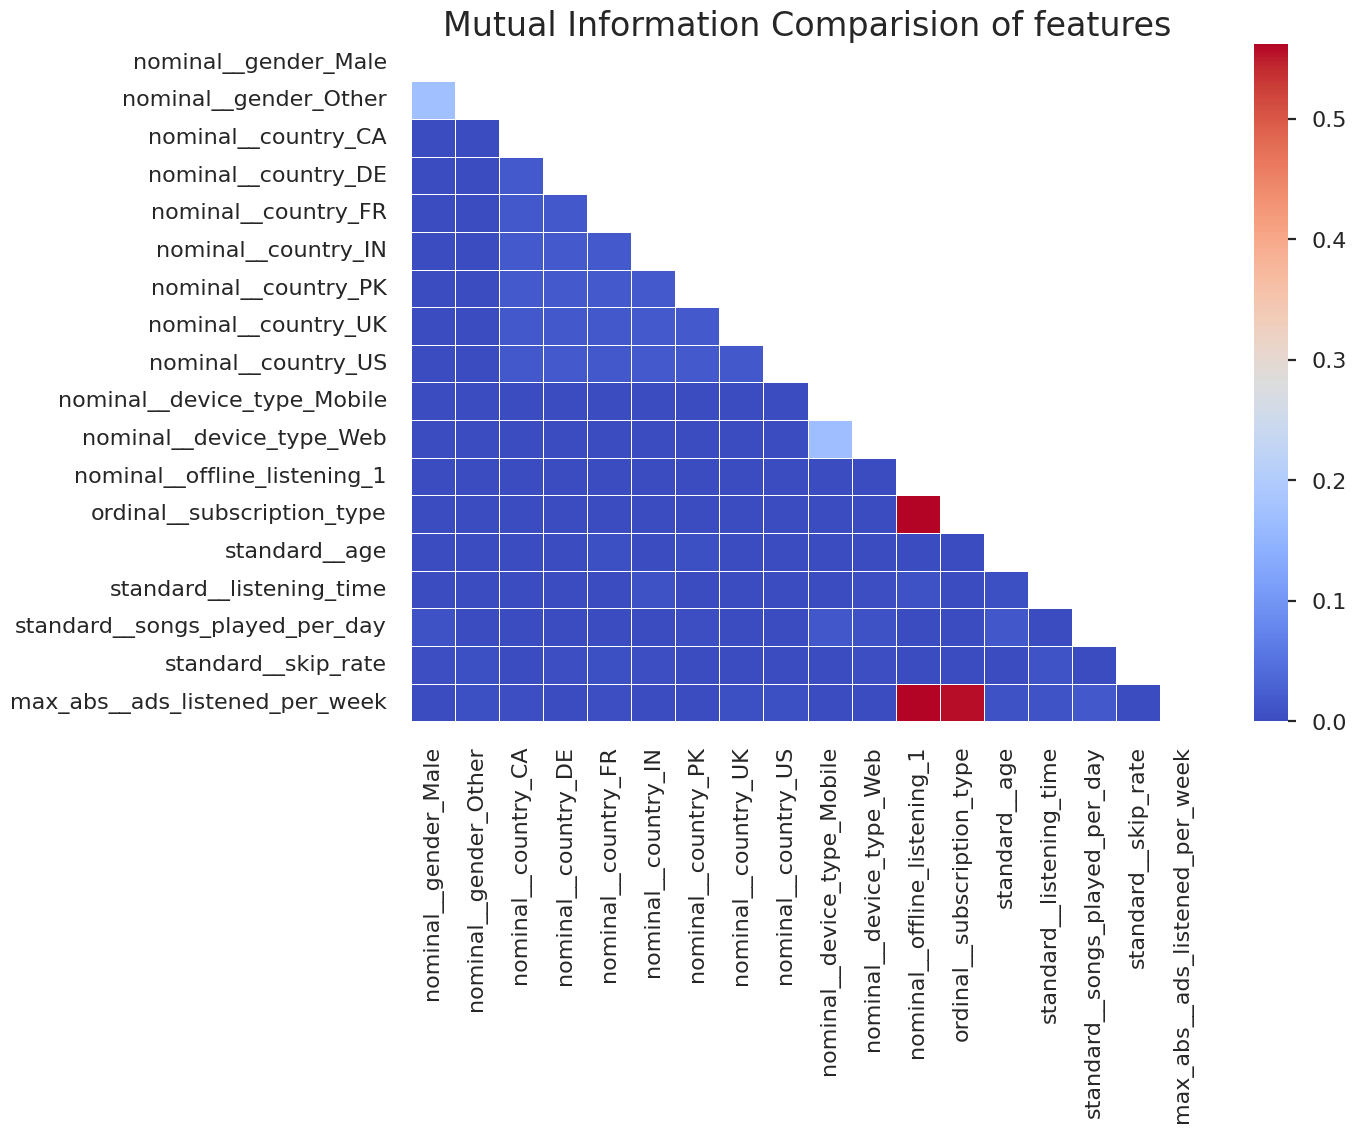

In [ ]:
ax = sns.heatmap(mutual_info_matrix,
            xticklabels=X_preprocessed_df.columns,
            yticklabels=X_preprocessed_df.columns,
            cmap='coolwarm',
            mask=np.triu(np.ones_like(mutual_info_matrix, dtype=bool)),
            linewidth=0.5);

ax.set_title('Mutual Information Comparision of features', fontsize=24);

We can see that three pairs of features have high mutual information:
- `nominal__offline_listening_1` and `ordinal__subscription_type`
- `nominal__offline_listening_1` and `max_abs__ads_listened_per_week`
- `ordinal__subscription_type` and `max_abs__ads_listened_per_week`

We should compute the mutual information between the three columns and the target variable, and drop the two that have the lowest mutual information.

In [ ]:
mi_offline = mutual_info_classif(X_preprocessed_df['nominal__offline_listening_1'].to_frame(),
                     y=y_train,
                     discrete_features=True,
                     random_state=RANDOM_STATE,
                     n_jobs=-1)

mi_subscription = mutual_info_classif(X_preprocessed_df['ordinal__subscription_type'].to_frame(),
                     y=y_train,
                     discrete_features=True,
                     random_state=RANDOM_STATE,
                     n_jobs=-1)

mi_ads = mutual_info_classif(X_preprocessed_df['max_abs__ads_listened_per_week'].to_frame(),
                     y=y_train,
                     discrete_features=False,
                     random_state=RANDOM_STATE,
                     n_jobs=-1)


display(f'The mutual information between nominal__offline_listening_1 and \
is_churned is: {mi_offline}')

display(f'The mutual information between ordinal__subscription_type and \
is_churned is: {mi_subscription}')

display(f'The mutual information between max_abs__ads_listened_per_week and \
is_churned is: {mi_ads}')

'The mutual information between nominal__offline_listening_1 and is_churned is: [4.4741381e-05]'

'The mutual information between ordinal__subscription_type and is_churned is: [0.00031112]'

'The mutual information between max_abs__ads_listened_per_week and is_churned is: [0]'

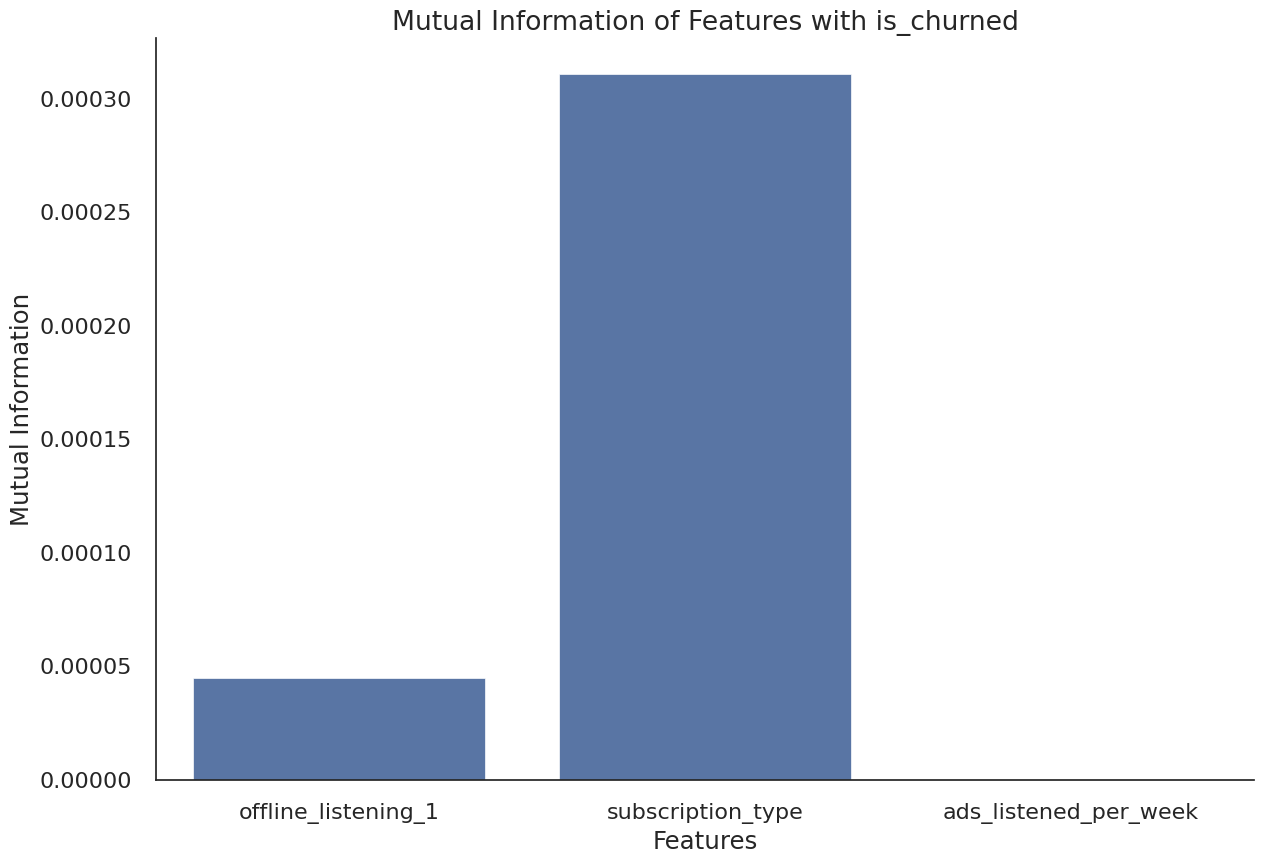

In [ ]:
mi_sns_df = pd.DataFrame({
    'Features': ['offline_listening_1', 'subscription_type',
                 'ads_listened_per_week'],
    'Mutual Information': [mi_offline[0], mi_subscription[0], mi_ads[0]]
})

ax = sns.barplot(data=mi_sns_df, x='Features', y='Mutual Information');
ax.set_title('Mutual Information of Features with is_churned');
sns.despine();
plt.tight_layout()

Based on the above, `ordinal__subscription_type` has the highest mutual information with `is_churned`, so we should drop `nominal__offline_listening_1` and `max_abs__ads_listened_per_week`.

### Feature Elimination - Recursive Feature Elimination with Cross Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rfecv = RFECV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    step=1,
    cv=cv,
    scoring='roc_auc', # Chosen because we want to minimize FNs and FPs
    n_jobs=-1
)
rfecv.fit(X_preprocessed_df, y_train)

selected_features_dtree = rfecv.get_feature_names_out()
n_features_dtree = rfecv.n_features_
dtree_scores = rfecv.cv_results_['mean_test_score']

print(f"Number of features that given largest ROC-AUC: {n_features_dtree}\n")
print(f'Features not selected by rfecv with DecisionTreeClassifier:\
 {set(X_preprocessed_df.columns).difference(set(selected_features_dtree))}\n')
selected_features_dtree

Number of features that given largest ROC-AUC: 17

Features not selected by rfecv with DecisionTreeClassifier: {'nominal__country_IN'}



array(['nominal__gender_Male', 'nominal__gender_Other',
       'nominal__country_CA', 'nominal__country_DE',
       'nominal__country_FR', 'nominal__country_PK',
       'nominal__country_UK', 'nominal__country_US',
       'nominal__device_type_Mobile', 'nominal__device_type_Web',
       'nominal__offline_listening_1', 'ordinal__subscription_type',
       'standard__age', 'standard__listening_time',
       'standard__songs_played_per_day', 'standard__skip_rate',
       'max_abs__ads_listened_per_week'], dtype=object)

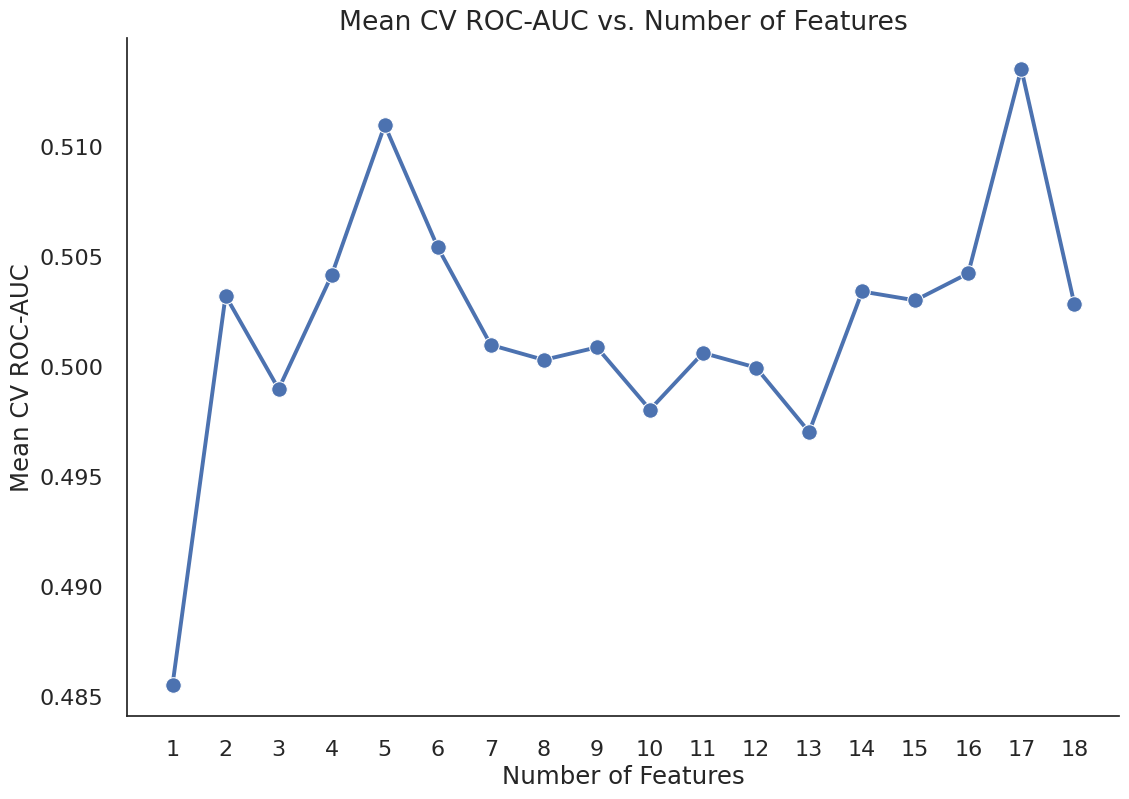

In [ ]:
# Number of features evaluated by RFECV
n_feats = np.arange(1, len(X_preprocessed_df.columns) + 1)

# I create a tidy DataFrame for plotting
rfecv_df = pd.DataFrame({
    "Number of Features": n_feats,
    "Mean CV ROC-AUC": dtree_scores
})

ax = sns.lineplot(
    data=rfecv_df,
    x="Number of Features",
    y="Mean CV ROC-AUC",
    marker="o"
)

ax.set_title('Mean CV ROC-AUC vs. Number of Features');
ax.set_xticks(np.arange(1,19));
sns.despine();

### Sequential Feature Selection

In [ ]:
model = KNeighborsClassifier(n_neighbors = 5)

In [ ]:
sfs_churn = SFS(estimator = model, n_features_to_select = 15, direction = 'forward', scoring = 'roc_auc', cv = 5, n_jobs = -1)
sfs_churn.fit(X_preprocessed_df, y_train)
sfs_features = X_preprocessed_df.columns[list(sfs_churn.get_support())]
sfs_features

Index(['nominal__gender_Male', 'nominal__gender_Other', 'nominal__country_CA',
       'nominal__country_DE', 'nominal__country_FR', 'nominal__country_IN',
       'nominal__country_PK', 'nominal__country_UK', 'nominal__country_US',
       'nominal__offline_listening_1', 'standard__age',
       'standard__listening_time', 'standard__songs_played_per_day',
       'standard__skip_rate', 'max_abs__ads_listened_per_week'],
      dtype='object')

In [ ]:
print(f'Features not selected by SFS for KNN: \
{set(X_preprocessed_df.columns).difference(set(sfs_features))}')

Features not selected by SFS for KNN: {'nominal__device_type_Mobile', 'nominal__device_type_Web', 'ordinal__subscription_type'}


### Findings of Feature Elimination Techniques
- Constant / Quasiconstant features
  - No features were constant / quasiconstant

- Mutual Information
  - We used Mutual Information to view each features "correlation" with each other, this method proved useful and we found the features `nominal__offline_listening_1`, `ordinal__subscription_type`, and `max_abs__ads_listened_per_week` to be highly "correlated". We did not use pearson correlation as many of our features are categorical.
  - Upon testing the three features above with the target `is_churned`, the mutual information varied wildly based on the `random_state` parameter. We could not trade this variance off without introducing bias.

- Recursive Feature Elimination for `DecisionTreeClassifer()`
  - We used `RFECV` with `ROC-AUC` scoring and found we achieved the highest mean score with all features except for `nominal__country_IN`

- Sequential Feature Selection (`SFS`) for `KNeighborsClassifier`.
  - Since our total number of features is relatively small ($18$), we ran it with selecting $15$ columns, and found that it didn't select `nominal__device_type_Mobile`, `ordinal__subscription_type`, and `nominal__device_type_Web`.

  ### Potential improvements
- Mutual Information Improvements
  - Run the mutual information code between the three highly mutual features and the target variable multiple times to build a confidence interval for true mutual information with the target.

- Sequential Feature Selection (`SFS`) Improvements.
  - Run `SFS` with `KNeighborsClassifier` multiple times incrementing `n_features_to_select`, capture the `ROC-AUC` score, and determine where the global maximum is
  - Run `SFS` with `LogisticRegression`. This was too computational intensive to be done in a short amount of time. Iterate as we would with `KNeighborsClassifer`.


## Exporting cleaned data
Note that these are all saved in the runtime. You must manually download them in the files tab.

In [ ]:
# Apply transform to X_test
X_train_df = pd.DataFrame(X_preprocessed, columns = X_preprocessed_names)
X_train_df.head()

X_test = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test, columns = X_preprocessed_names)

# Save files
X_train_df.to_csv('X_train.csv', index=False)
X_test_df.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)